## 1. Valorisation des options avec le modèle de Black-Scholes

Dans le cadre de ce projet de **Counterparty Credit Risk**, nous devons être capables de valoriser les instruments financiers composant le portefeuille.

Nous commençons par des options européennes simples (Call et Put). Le modèle de Black-Scholes permet de déterminer leur valeur théorique à partir du prix du sous-jacent, du prix d'exercice, de la volatilité, du taux sans risque et de la maturité.

### Prix d'un Call européen

Le prix d'un Call européen est donné par :

$$
C = S_0 N(d_1) - K e^{-rT} N(d_2)
$$

### Prix d'un Put européen

Le prix d'un Put européen est donné par :

$$
P = K e^{-rT} N(-d_2) - S_0 N(-d_1)
$$

avec :

$$
d_1 =
\frac{
\ln\left(\frac{S_0}{K}\right)
+
\left(r+\frac{1}{2}\sigma^2\right)T
}{
\sigma\sqrt{T}
}
$$

et :

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

où :

- $S_0$ : prix actuel de l'actif sous-jacent ;
- $K$ : prix d'exercice (strike) de l'option ;
- $r$ : taux d'intérêt sans risque ;
- $\sigma$ : volatilité du sous-jacent ;
- $T$ : temps restant jusqu'à la maturité ;
- $N(\cdot)$ : fonction de répartition de la loi normale centrée réduite.

## 2. Simulation Monte Carlo des facteurs de marché

Afin d'estimer le risque de contrepartie, il est nécessaire de simuler l'évolution future des facteurs de marché qui influencent la valeur des produits dérivés.

Dans cette première version du moteur, nous considérons un actif financier dont le prix suit un **mouvement brownien géométrique**.

Sous la mesure risque-neutre, la dynamique du prix du sous-jacent est donnée par :

$$
dS_t = rS_tdt + \sigma S_tdW_t
$$

où :

- $S_t$ : prix du sous-jacent à la date $t$ ;
- $r$ : taux d'intérêt sans risque ;
- $\sigma$ : volatilité du sous-jacent ;
- $W_t$ : mouvement brownien standard.

Pour réaliser une simulation numérique, nous utilisons la forme discrétisée suivante :

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(r-\frac{1}{2}\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right]
$$

avec :

$$
Z \sim \mathcal{N}(0,1)
$$

Chaque simulation représente un scénario possible d'évolution future du marché.

En générant plusieurs milliers de trajectoires, nous obtenons une distribution des prix futurs du sous-jacent, qui sera ensuite utilisée pour revaloriser les produits dérivés et calculer les expositions futures.

### 2.1 Paramétrage de la simulation

Nous définissons les paramètres nécessaires à la simulation Monte Carlo du prix du sous-jacent.

Dans cette première approche, nous considérons les hypothèses suivantes :

- Prix initial du sous-jacent : $S_0 = 100$
- Taux sans risque : $r = 3\%$
- Volatilité annuelle : $\sigma = 20\%$
- Horizon de simulation : $T = 1$ an
- Nombre de pas de temps : $52$
- Nombre de simulations : $10\,000$

L'horizon d'un an est ainsi divisé en 52 intervalles, correspondant approximativement à une fréquence hebdomadaire.

Le pas de temps est défini par :

$$
\Delta t = \frac{T}{N}
$$

où $N$ représente le nombre de pas de temps.

L'utilisation de 10 000 simulations permet de générer un ensemble suffisamment large de scénarios de marché pour étudier la distribution des valeurs futures du sous-jacent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de marché
S0 = 100
r = 0.03
sigma = 0.20
T = 1.0

# Paramètres de simulation
n_steps = 52
n_sims = 10_000

# Pas de temps
dt = T / n_steps

print(f"Prix initial du sous-jacent : {S0} €")
print(f"Taux sans risque : {r:.2%}")
print(f"Volatilité annuelle : {sigma:.2%}")
print(f"Horizon : {T} an")
print(f"Nombre de pas de temps : {n_steps}")
print(f"Nombre de simulations : {n_sims:,}")
print(f"Pas de temps Δt : {dt:.6f}")

Prix initial du sous-jacent : 100 €
Taux sans risque : 3.00%
Volatilité annuelle : 20.00%
Horizon : 1.0 an
Nombre de pas de temps : 52
Nombre de simulations : 10,000
Pas de temps Δt : 0.019231


### 2.2 Génération des trajectoires Monte Carlo

À partir des paramètres définis précédemment, nous générons maintenant plusieurs scénarios d'évolution future du prix du sous-jacent.

À chaque pas de temps, nous générons une variable aléatoire :

$$
Z \sim \mathcal{N}(0,1)
$$

Cette variable représente le choc aléatoire de marché appliqué au sous-jacent.

Le prix est ensuite mis à jour selon :

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(r-\frac{1}{2}\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right]
$$

En répétant ce processus pour chaque date et chaque simulation, nous obtenons une matrice de trajectoires représentant différents scénarios possibles d'évolution du marché.

Nous utilisons également une graine aléatoire (`seed`) afin de rendre les résultats reproductibles.

In [2]:
# Générateur de nombres aléatoires
rng = np.random.default_rng(seed=42)

# Génération des chocs aléatoires
Z = rng.standard_normal(size=(n_sims, n_steps))

print("Dimension de la matrice Z :", Z.shape)

Dimension de la matrice Z : (10000, 52)


### Construisons maintenant les variations de prix

In [3]:
# Calcul des variations logarithmiques du prix
increments = (
    (r - 0.5 * sigma**2) * dt
    + sigma * np.sqrt(dt) * Z
)

print("Dimension des variations :", increments.shape)

Dimension des variations : (10000, 52)


### Construire les trajectoires complètes

In [4]:
# Somme cumulée des variations logarithmiques
log_paths = np.cumsum(increments, axis=1)

# Création de la matrice des prix
paths = np.empty((n_sims, n_steps + 1))

# Tous les scénarios commencent au même prix S0
paths[:, 0] = S0

# Construction des trajectoires de prix
paths[:, 1:] = S0 * np.exp(log_paths)

# Grille temporelle
times = np.linspace(0, T, n_steps + 1)

print("Dimension finale :", paths.shape)

Dimension finale : (10000, 53)


### Vérifions quelques trajectoires

In [5]:
print("Première trajectoire :")
print(np.round(paths[0, :10], 2))

print("\nDeuxième trajectoire :")
print(np.round(paths[1, :10], 2))

Première trajectoire :
[100.   100.87  98.02 100.1  102.77  97.37  93.94  94.29  93.48  93.46]

Deuxième trajectoire :
[100.    96.06  95.23  94.01  92.38  91.69  95.59  93.34  95.9   91.55]


### 2.3 Visualisation des trajectoires simulées

Après avoir généré les 10 000 scénarios Monte Carlo, nous visualisons un sous-ensemble des trajectoires afin d'observer les différentes évolutions possibles du prix du sous-jacent.

Toutes les trajectoires commencent au même prix initial $S_0 = 100$, puis évoluent différemment sous l'effet des chocs aléatoires de marché.

Pour conserver un graphique lisible, nous affichons uniquement 20 trajectoires parmi les 10 000 simulations générées.

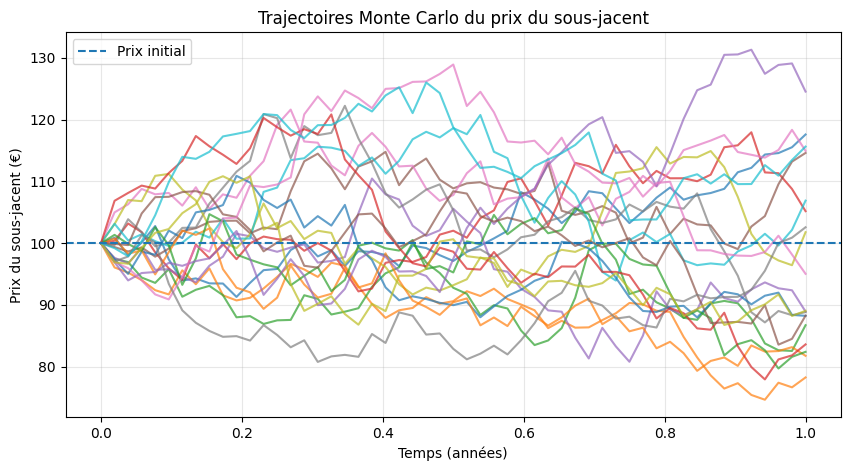

In [6]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.plot(times, paths[i], alpha=0.7)

plt.axhline(
    y=S0,
    linestyle="--",
    label="Prix initial"
)

plt.title("Trajectoires Monte Carlo du prix du sous-jacent")
plt.xlabel("Temps (années)")
plt.ylabel("Prix du sous-jacent (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 2.4 Validation de la simulation Monte Carlo

Avant d'utiliser les trajectoires simulées pour mesurer le risque de contrepartie, nous vérifions la cohérence du moteur Monte Carlo.

Sous la mesure risque-neutre, l'espérance du prix du sous-jacent à la maturité est donnée par :

$$
\mathbb{E}^{Q}[S_T] = S_0 e^{rT}
$$

La moyenne des prix terminaux obtenus par simulation Monte Carlo doit donc être proche de cette valeur théorique.

Un léger écart est attendu en raison de l'erreur d'échantillonnage liée au nombre fini de simulations.

In [7]:
# Prix obtenus à la dernière date de simulation
terminal_prices = paths[:, -1]

# Moyenne Monte Carlo
mean_simulated = np.mean(terminal_prices)

# Espérance théorique sous la mesure risque-neutre
mean_theoretical = S0 * np.exp(r * T)

# Écart absolu
absolute_error = abs(mean_simulated - mean_theoretical)

# Écart relatif
relative_error = absolute_error / mean_theoretical

print(f"Moyenne simulée     : {mean_simulated:.4f} €")
print(f"Moyenne théorique   : {mean_theoretical:.4f} €")
print(f"Écart absolu        : {absolute_error:.4f} €")
print(f"Écart relatif       : {relative_error:.4%}")

Moyenne simulée     : 102.9491 €
Moyenne théorique   : 103.0455 €
Écart absolu        : 0.0964 €
Écart relatif       : 0.0935%


### 2.5 Distribution du prix du sous-jacent à maturité

Les simulations Monte Carlo permettent également d'étudier la distribution des prix possibles du sous-jacent à la maturité.

Nous analysons notamment :

- la moyenne ;
- la médiane ;
- l'écart-type ;
- les quantiles à 5 % et 95 %.

Cette analyse permet de mieux comprendre la dispersion des scénarios de marché générés avant de les utiliser pour la revalorisation des produits dérivés.

In [8]:
print(f"Moyenne      : {np.mean(terminal_prices):.2f} €")
print(f"Médiane      : {np.median(terminal_prices):.2f} €")
print(f"Écart-type   : {np.std(terminal_prices):.2f} €")
print(f"Quantile 5%  : {np.quantile(terminal_prices, 0.05):.2f} €")
print(f"Quantile 95% : {np.quantile(terminal_prices, 0.95):.2f} €")

Moyenne      : 102.95 €
Médiane      : 100.94 €
Écart-type   : 20.76 €
Quantile 5%  : 72.38 €
Quantile 95% : 140.59 €


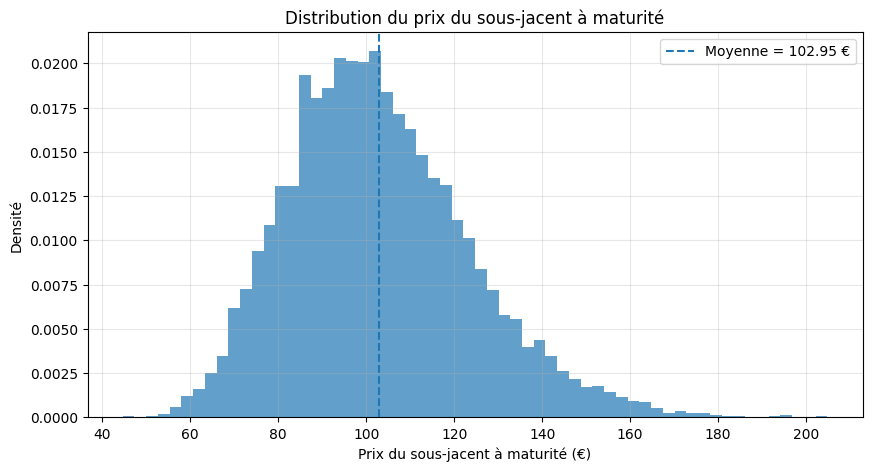

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    terminal_prices,
    bins=60,
    density=True,
    alpha=0.7
)

plt.axvline(
    mean_simulated,
    linestyle="--",
    label=f"Moyenne = {mean_simulated:.2f} €"
)

plt.title("Distribution du prix du sous-jacent à maturité")
plt.xlabel("Prix du sous-jacent à maturité (€)")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interprétation

Les trajectoires Monte Carlo montrent plusieurs évolutions possibles du prix du sous-jacent à partir d'un même prix initial.

La moyenne des prix simulés à maturité est proche de l'espérance théorique $S_0e^{rT}$, ce qui confirme la cohérence de la simulation sous la mesure risque-neutre.

La distribution des prix terminaux est asymétrique et positive, conformément à l'hypothèse de mouvement brownien géométrique.

Le moteur Monte Carlo peut désormais être utilisé pour simuler les valeurs futures des produits dérivés et construire les expositions au risque de contrepartie.

## 3. Valorisation future du dérivé

Après avoir simulé l'évolution future du sous-jacent, nous utilisons maintenant ces trajectoires pour revaloriser le produit dérivé à chaque date future.

Pour chaque scénario Monte Carlo et chaque date de simulation, la valeur du dérivé dépend notamment :

- du prix simulé du sous-jacent $S_t$ ;
- du prix d'exercice $K$ ;
- du taux sans risque $r$ ;
- de la volatilité $\sigma$ ;
- du temps restant jusqu'à la maturité.

Nous considérons dans un premier temps un **Call européen**.

À chaque date $t$, le temps restant jusqu'à maturité est :

$$
\tau = T - t
$$

Le Call est ensuite revalorisé avec la formule de Black-Scholes en remplaçant le prix initial $S_0$ par le prix simulé $S_t$.

Cette revalorisation permet d'obtenir le **Mark-to-Market futur (Future MtM)** du dérivé dans chaque scénario.

In [10]:
# Paramètres du dérivé
K = 100          # Prix d'exercice
option_type = "call"

print(f"Strike : {K} €")
print(f"Type d'option : {option_type}")

Strike : 100 €
Type d'option : call


### Fonction Black-Scholes adaptée à la simulation

In [11]:
from scipy.stats import norm

def black_scholes_call_vectorized(S, K, r, sigma, tau):
    """
    Valorisation vectorisée d'un Call européen avec Black-Scholes.

    Parameters
    ----------
    S : array-like
        Prix simulés du sous-jacent.
    K : float
        Prix d'exercice.
    r : float
        Taux sans risque.
    sigma : float
        Volatilité.
    tau : float
        Temps restant jusqu'à maturité.

    Returns
    -------
    array-like
        Valeurs du Call.
    """

    # À maturité : payoff du Call
    if tau <= 0:
        return np.maximum(S - K, 0.0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    call_value = (
        S * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )

    return call_value

### Construction de la matrice Future MtM

In [12]:
# Matrice des valeurs futures du dérivé
future_mtm = np.empty_like(paths)

for j, t in enumerate(times):

    tau = T - t

    future_mtm[:, j] = black_scholes_call_vectorized(
        S=paths[:, j],
        K=K,
        r=r,
        sigma=sigma,
        tau=tau
    )

print("Dimension de la matrice Future MtM :", future_mtm.shape)

Dimension de la matrice Future MtM : (10000, 53)


### Vérification de la valeur initiale

In [13]:
initial_mtm = future_mtm[:, 0]

print("Valeur moyenne du Call à t=0 :", initial_mtm.mean())
print("Écart-type à t=0 :", initial_mtm.std())

Valeur moyenne du Call à t=0 : 9.41340338385302
Écart-type à t=0 : 3.552713678800501e-15


In [14]:
print("Premières valeurs à t=0 :")
print(initial_mtm[:5])

Premières valeurs à t=0 :
[9.41340338 9.41340338 9.41340338 9.41340338 9.41340338]


### Vérification à maturité

In [15]:
terminal_mtm = future_mtm[:, -1]

terminal_payoff = np.maximum(
    terminal_prices - K,
    0.0
)

difference = np.max(
    np.abs(
        terminal_mtm - terminal_payoff
    )
)

print(
    "Écart maximum entre MtM final et payoff :",
    difference
)

Écart maximum entre MtM final et payoff : 0.0


### Interprétation du Future Mark-to-Market

La matrice `future_mtm` contient la valeur future du Call pour chaque scénario Monte Carlo et chaque date de simulation.

À la date initiale, tous les scénarios ont la même valeur puisque le prix du sous-jacent est identique.

Au fur et à mesure que les trajectoires de marché divergent, les valeurs du dérivé deviennent différentes selon les scénarios.

À maturité, la valeur du Call correspond à son payoff :

$$
V_T = \max(S_T - K, 0)
$$

Cette matrice de Mark-to-Market futur constitue la base du calcul des expositions au risque de contrepartie.

## 4. Calcul des expositions au risque de contrepartie

Le risque de contrepartie correspond au risque de perte subi si la contrepartie fait défaut alors que la valeur du portefeuille est positive pour l'établissement financier.

À chaque date future, l'exposition est donc définie comme la partie positive du Mark-to-Market :

$$
E_t = \max(V_t, 0)
$$

où :

- $V_t$ représente la valeur future du dérivé ;
- $E_t$ représente l'exposition à la contrepartie.

Si le Mark-to-Market est négatif, l'exposition de crédit est considérée comme nulle du point de vue de l'établissement.

À partir de la distribution des expositions simulées, nous pouvons calculer plusieurs indicateurs importants de risque de contrepartie :

- Expected Exposure (EE) ;
- Expected Positive Exposure (EPE) ;
- Potential Future Exposure (PFE).

### Calcul de la Future Exposure

In [16]:
# Calcul des expositions positives
exposure = np.maximum(future_mtm, 0.0)

print("Dimension de la matrice d'exposition :", exposure.shape)

Dimension de la matrice d'exposition : (10000, 53)


### 4.2 Expected Exposure (EE)

L'Expected Exposure représente l'exposition moyenne à une contrepartie à une date future donnée.

Elle est définie par :

$$
EE(t) = \mathbb{E}[E_t]
$$

Dans le cadre de notre simulation Monte Carlo, elle est estimée par :

$$
EE(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
E_t^{(i)}
$$

où :

- $N$ représente le nombre de simulations ;
- $E_t^{(i)}$ représente l'exposition du scénario $i$ à la date $t$.

L'EE permet ainsi de construire un profil moyen d'exposition au cours du temps.

In [17]:
# Expected Exposure à chaque date
EE = np.mean(exposure, axis=0)

print("Dimension du profil EE :", EE.shape)

print(f"EE à t=0       : {EE[0]:.4f} €")
print(f"EE à 6 mois    : {EE[n_steps // 2]:.4f} €")
print(f"EE à maturité  : {EE[-1]:.4f} €")

Dimension du profil EE : (53,)
EE à t=0       : 9.4134 €
EE à 6 mois    : 9.5378 €
EE à maturité  : 9.6327 €


### 4.4 Potential Future Exposure (PFE)

Le Potential Future Exposure mesure un niveau élevé mais plausible d'exposition future.

Contrairement à l'Expected Exposure, qui correspond à une moyenne, le PFE correspond à un quantile de la distribution des expositions.

Par exemple, le PFE à 95 % est défini par :

$$
PFE_{95\%}(t)
=
Q_{95\%}(E_t)
$$

Cela signifie qu'à une date donnée, 95 % des scénarios simulés présentent une exposition inférieure ou égale à ce niveau.

Dans ce projet, nous calculons les PFE à 95 % et 99 %.

In [18]:
# Potential Future Exposure
PFE_95 = np.quantile(
    exposure,
    0.95,
    axis=0
)

PFE_99 = np.quantile(
    exposure,
    0.99,
    axis=0
)

print(f"PFE 95% à 6 mois : {PFE_95[n_steps // 2]:.4f} €")
print(f"PFE 99% à 6 mois : {PFE_99[n_steps // 2]:.4f} €")

PFE 95% à 6 mois : 28.6998 €
PFE 99% à 6 mois : 41.0343 €


## EE vs PFE

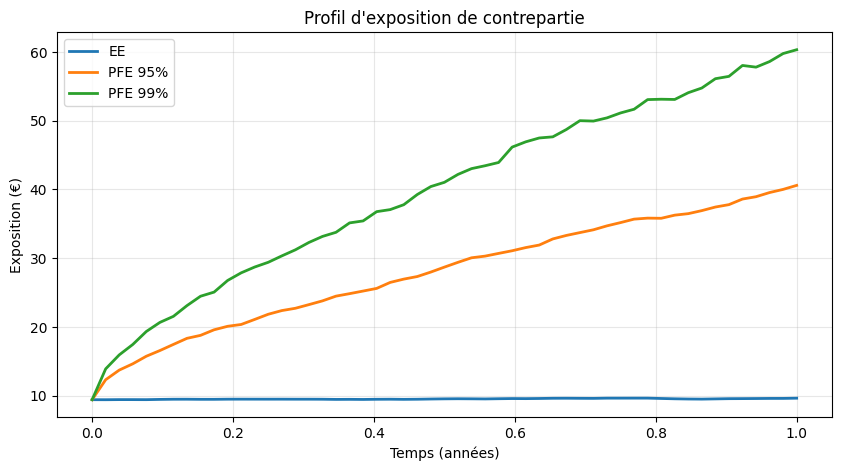

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    EE,
    linewidth=2,
    label="EE"
)

plt.plot(
    times,
    PFE_95,
    linewidth=2,
    label="PFE 95%"
)

plt.plot(
    times,
    PFE_99,
    linewidth=2,
    label="PFE 99%"
)

plt.title("Profil d'exposition de contrepartie")
plt.xlabel("Temps (années)")
plt.ylabel("Exposition (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4.6 Expected Positive Exposure (EPE)

L'Expected Positive Exposure est une mesure synthétique obtenue à partir du profil d'Expected Exposure.

Dans une approche discrète simplifiée, nous pouvons calculer :

$$
EPE
=
\frac{1}{M}
\sum_{j=1}^{M}
EE(t_j)
$$

où $M$ représente le nombre de dates futures considérées.

L'EPE fournit ainsi une mesure moyenne de l'exposition positive sur l'horizon étudié.

In [20]:
# Expected Positive Exposure
EPE = np.mean(EE)

print(f"Expected Positive Exposure : {EPE:.4f} €")

Expected Positive Exposure : 9.5253 €


## Résumé des indicateurs

In [21]:
risk_metrics = {
    "Initial MtM": future_mtm[0, 0],
    "EPE": EPE,
    "Max EE": np.max(EE),
    "Max PFE 95%": np.max(PFE_95),
    "Max PFE 99%": np.max(PFE_99)
}

for metric, value in risk_metrics.items():
    print(f"{metric:<15}: {value:,.4f} €")

Initial MtM    : 9.4134 €
EPE            : 9.5253 €
Max EE         : 9.6418 €
Max PFE 95%    : 40.5900 €
Max PFE 99%    : 60.3231 €


### Interprétation

Les simulations Monte Carlo permettent désormais de transformer les scénarios de marché en profils d'exposition au risque de contrepartie.

L'Expected Exposure mesure l'exposition moyenne à chaque date, tandis que le Potential Future Exposure fournit une mesure plus conservatrice basée sur les quantiles élevés de la distribution.

L'Expected Positive Exposure résume le niveau moyen d'exposition positive sur l'ensemble de l'horizon étudié.

Ces indicateurs constituent les principales briques nécessaires à l'estimation de la Credit Valuation Adjustment (CVA).

## 5. Credit Valuation Adjustment (CVA)

Les indicateurs EE, EPE et PFE permettent de mesurer l'exposition future envers une contrepartie. Cependant, ils ne prennent pas directement en compte la probabilité que cette contrepartie fasse défaut.

La **Credit Valuation Adjustment (CVA)** représente l'ajustement de valeur associé au risque de défaut de la contrepartie.

Elle peut être interprétée comme la valeur actualisée de la perte attendue liée au risque de contrepartie.

Dans une approche simplifiée, la CVA dépend principalement de trois éléments :

- l'exposition future attendue envers la contrepartie ;
- la probabilité de défaut de la contrepartie ;
- la proportion de l'exposition qui ne serait pas récupérée après le défaut.

Cette dernière composante est appelée **Loss Given Default (LGD)**.

### 5.1 Recovery Rate et Loss Given Default

Lorsqu'une contrepartie fait défaut, l'établissement financier ne perd pas nécessairement la totalité de son exposition.

Le **Recovery Rate**, noté $R$, représente la proportion de l'exposition qui peut être récupérée après le défaut.

La Loss Given Default est alors définie par :

$$
LGD = 1 - R
$$

Par exemple, avec un taux de recouvrement de 40 % :

$$
R = 40\%
$$

et donc :

$$
LGD = 60\%
$$

Cela signifie que, dans notre hypothèse simplifiée, 60 % de l'exposition serait perdue en cas de défaut.

In [22]:
# Hypothèses de récupération
recovery_rate = 0.40
LGD = 1 - recovery_rate

print(f"Recovery Rate : {recovery_rate:.2%}")
print(f"Loss Given Default : {LGD:.2%}")

Recovery Rate : 40.00%
Loss Given Default : 60.00%


### 5.2 Modélisation du défaut par un Hazard Rate

Pour cette première version du moteur, nous utilisons un **hazard rate constant**, noté $\lambda$.

Le hazard rate représente l'intensité instantanée de défaut de la contrepartie, conditionnellement à sa survie jusqu'à la date considérée.

Sous l'hypothèse d'un hazard rate constant, la probabilité de survie jusqu'à la date $t$ est :

$$
S(t) = e^{-\lambda t}
$$

La probabilité cumulée de défaut avant la date $t$ est alors :

$$
PD(0,t) = 1 - e^{-\lambda t}
$$

Dans cette première implémentation, nous supposons :

$$
\lambda = 2\%
$$

Cette hypothèse est volontairement simplifiée. Dans une application de marché, le hazard rate pourrait notamment être calibré à partir de spreads de CDS ou d'autres informations de crédit.

In [23]:
# Hazard rate annuel
hazard_rate = 0.02

# Probabilités de survie
survival_prob = np.exp(
    -hazard_rate * times
)

# Probabilités cumulées de défaut
cumulative_pd = 1 - survival_prob

print(
    f"Probabilité de défaut à 1 an : "
    f"{cumulative_pd[-1]:.4%}"
)

Probabilité de défaut à 1 an : 1.9801%


## Visualisation de la survie et du défaut

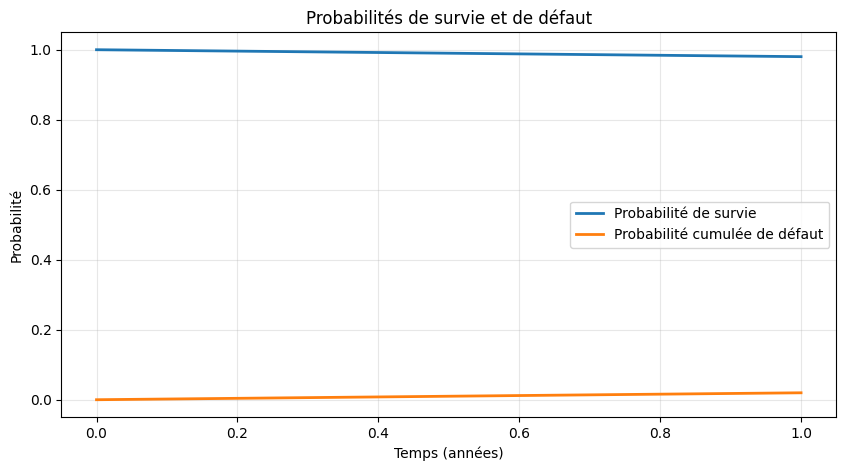

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    survival_prob,
    linewidth=2,
    label="Probabilité de survie"
)

plt.plot(
    times,
    cumulative_pd,
    linewidth=2,
    label="Probabilité cumulée de défaut"
)

plt.title("Probabilités de survie et de défaut")
plt.xlabel("Temps (années)")
plt.ylabel("Probabilité")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5.4 Probabilité marginale de défaut

Pour le calcul de la CVA, nous devons déterminer la probabilité de défaut sur chaque intervalle de temps.

La probabilité de défaut entre deux dates successives $t_{i-1}$ et $t_i$ est donnée par :

$$
\Delta PD_i
=
S(t_{i-1}) - S(t_i)
$$

où $S(t)$ représente la probabilité de survie.

Ces probabilités marginales permettent d'associer à chaque période une exposition attendue et une probabilité de défaut correspondante.

In [25]:
# Probabilités marginales de défaut
marginal_pd = (
    survival_prob[:-1]
    - survival_prob[1:]
)

print(
    "Nombre d'intervalles :",
    len(marginal_pd)
)

print(
    "Somme des PD marginales :",
    marginal_pd.sum()
)

print(
    "PD cumulée à 1 an :",
    cumulative_pd[-1]
)

Nombre d'intervalles : 52
Somme des PD marginales : 0.019801326693244747
PD cumulée à 1 an : 0.019801326693244747


### 5.5 Facteurs d'actualisation

Les pertes potentielles futures doivent être actualisées afin d'exprimer la CVA en valeur présente.

Sous l'hypothèse d'un taux sans risque constant $r$, le facteur d'actualisation à la date $t$ est :

$$
DF(t)=e^{-rt}
$$

In [26]:
discount_factors = np.exp(
    -r * times
)

print(
    f"Facteur d'actualisation à 1 an : "
    f"{discount_factors[-1]:.6f}"
)

Facteur d'actualisation à 1 an : 0.970446


### 5.6 Calcul de la CVA

Dans notre modèle discret simplifié, la CVA est calculée comme la somme des pertes attendues actualisées sur les différents intervalles :

$$
CVA
=
LGD
\sum_{i=1}^{M}
DF(t_i)
\times
EE(t_i)
\times
\Delta PD_i
$$

où :

- $LGD$ représente la Loss Given Default ;
- $DF(t_i)$ représente le facteur d'actualisation ;
- $EE(t_i)$ représente l'Expected Exposure ;
- $\Delta PD_i$ représente la probabilité marginale de défaut sur l'intervalle considéré.

Cette formulation suppose notamment que l'exposition et le défaut sont indépendants. Les effets de dépendance entre risque de marché et risque de crédit pourront être étudiés ultérieurement dans le cadre du Wrong-Way Risk.

In [27]:
# On utilise les dates futures t1,...,t52
EE_future = EE[1:]

DF_future = discount_factors[1:]

# Contribution de chaque intervalle à la CVA
cva_contributions = (
    LGD
    * DF_future
    * EE_future
    * marginal_pd
)

# CVA totale
CVA = np.sum(cva_contributions)

print(f"CVA du portefeuille : {CVA:,.4f} €")

CVA du portefeuille : 0.1115 €


## Visualiser les contributions à la CVA

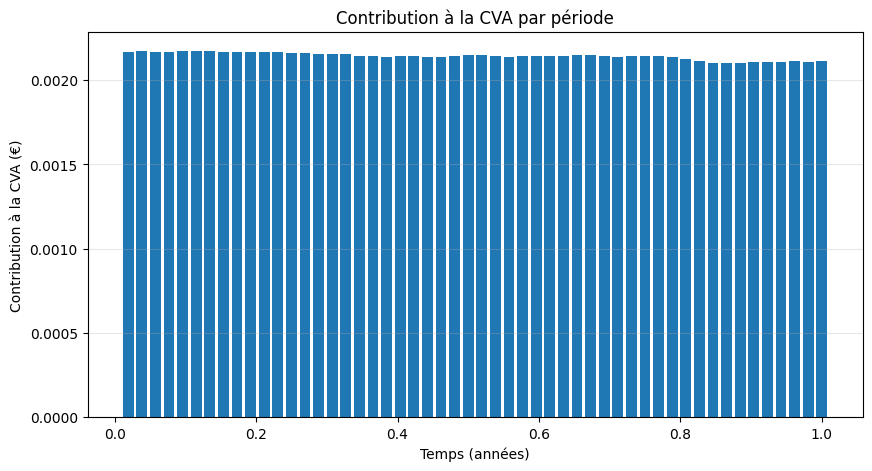

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    times[1:],
    cva_contributions,
    width=dt * 0.8
)

plt.title("Contribution à la CVA par période")
plt.xlabel("Temps (années)")
plt.ylabel("Contribution à la CVA (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Résumé Counterparty Risk

In [29]:
import pandas as pd

summary = pd.DataFrame({
    "Indicateur": [
        "Expected Positive Exposure",
        "Maximum EE",
        "Maximum PFE 95%",
        "Maximum PFE 99%",
        "Recovery Rate",
        "Hazard Rate",
        "PD cumulée à 1 an",
        "CVA"
    ],
    "Valeur": [
        f"{EPE:,.2f} €",
        f"{np.max(EE):,.2f} €",
        f"{np.max(PFE_95):,.2f} €",
        f"{np.max(PFE_99):,.2f} €",
        f"{recovery_rate:.2%}",
        f"{hazard_rate:.2%}",
        f"{cumulative_pd[-1]:.2%}",
        f"{CVA:,.2f} €"
    ]
})

summary

,Indicateur,Valeur
0,Expected Positive Exposure,9.53 €
1,Maximum EE,9.64 €
2,Maximum PFE 95%,40.59 €
3,Maximum PFE 99%,60.32 €
4,Recovery Rate,40.00%
5,Hazard Rate,2.00%
6,PD cumulée à 1 an,1.98%
7,CVA,0.11 €


## 6. Portefeuille de transactions et Netting

Jusqu'à présent, le risque de contrepartie a été étudié sur une seule option européenne.

Dans la pratique, une institution financière peut avoir plusieurs transactions avec une même contrepartie. Certaines positions peuvent avoir une valeur positive tandis que d'autres peuvent avoir une valeur négative.

L'exposition au risque de contrepartie dépend alors de la manière dont ces transactions sont agrégées.

Nous introduisons dans cette section le principe de **netting**, qui permet de compenser les valeurs positives et négatives des transactions appartenant à un même ensemble de compensation (netting set).

Nous comparerons deux situations :

1. l'exposition brute sans netting ;
2. l'exposition nette après compensation des transactions.

Cette comparaison permettra de mesurer l'effet du netting sur le profil d'exposition de la contrepartie.

### 6.1 Construction du portefeuille

Nous considérons un portefeuille simplifié composé de plusieurs options européennes sur le même sous-jacent.

Chaque transaction est caractérisée par :

- son type : Call ou Put ;
- son prix d'exercice ;
- sa quantité ;
- son sens de position.

Une quantité positive représente une position longue, tandis qu'une quantité négative représente une position courte.

Le portefeuille considéré est :

| Transaction | Produit | Strike | Quantité |
|---|---|---:|---:|
| T1 | Call | 90 | +100 |
| T2 | Call | 110 | -80 |
| T3 | Put | 95 | +60 |
| T4 | Put | 105 | -50 |

Cette structure permet d'obtenir des valeurs de marché positives et négatives selon les transactions et les scénarios.

In [30]:
portfolio = pd.DataFrame({
    "transaction": ["T1", "T2", "T3", "T4"],
    "type": ["call", "call", "put", "put"],
    "strike": [90, 110, 95, 105],
    "quantity": [100, -80, 60, -50]
})

portfolio

,transaction,type,strike,quantity
0,T1,call,90,100
1,T2,call,110,-80
2,T3,put,95,60
3,T4,put,105,-50


## Ajouter le pricing du Put

In [31]:
def black_scholes_put_vectorized(S, K, r, sigma, tau):
    """
    Valorisation vectorisée d'un Put européen avec Black-Scholes.
    """

    if tau <= 0:
        return np.maximum(K - S, 0.0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    put_value = (
        K * np.exp(-r * tau) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

    return put_value

### 6.3 Revalorisation du portefeuille

Chaque transaction est revalorisée à chaque date et pour chaque scénario Monte Carlo.

Pour une transaction $k$, son Mark-to-Market est donné par :

$$
V_t^{(k)}
=
q_k \times P_t^{(k)}
$$

où :

- $q_k$ représente la quantité de la transaction ;
- $P_t^{(k)}$ représente la valeur unitaire du produit dérivé.

Une position longue possède une quantité positive, tandis qu'une position courte possède une quantité négative.

Nous obtenons ainsi une distribution de Mark-to-Market pour chaque transaction, chaque scénario et chaque date future.

In [32]:
transaction_mtms = {}

for _, trade in portfolio.iterrows():

    trade_mtm = np.empty_like(paths)

    for j, t in enumerate(times):

        tau = T - t

        if trade["type"] == "call":

            unit_value = black_scholes_call_vectorized(
                paths[:, j],
                trade["strike"],
                r,
                sigma,
                tau
            )

        else:

            unit_value = black_scholes_put_vectorized(
                paths[:, j],
                trade["strike"],
                r,
                sigma,
                tau
            )

        trade_mtm[:, j] = (
            trade["quantity"] * unit_value
        )

    transaction_mtms[
        trade["transaction"]
    ] = trade_mtm

In [33]:
for trade, mtm in transaction_mtms.items():
    print(
        trade,
        mtm.shape,
        f"MtM initial = {mtm[0,0]:,.2f} €"
    )

T1 (10000, 53) MtM initial = 1,542.92 €
T2 (10000, 53) MtM initial = -423.47 €
T3 (10000, 53) MtM initial = 262.32 €
T4 (10000, 53) MtM initial = -451.24 €


### 6.4 Exposition brute sans netting

En l'absence de netting, les valeurs négatives de certaines transactions ne peuvent pas compenser les valeurs positives des autres transactions.

L'exposition brute est donc calculée en prenant la partie positive de chaque transaction avant de les additionner :

$$
E_t^{Gross}
=
\sum_{k=1}^{K}
\max(V_t^{(k)},0)
$$

Cette approche conduit généralement à une exposition plus élevée.

In [34]:
gross_exposure = np.zeros_like(paths)

for mtm in transaction_mtms.values():

    gross_exposure += np.maximum(
        mtm,
        0.0
    )

### 6.5 Exposition après netting

Lorsqu'un accord de netting juridiquement applicable existe entre les deux parties, les valeurs positives et négatives des transactions appartenant au même netting set peuvent être compensées.

Le Mark-to-Market net du portefeuille est :

$$
V_t^{Net}
=
\sum_{k=1}^{K}V_t^{(k)}
$$

L'exposition nette devient alors :

$$
E_t^{Net}
=
\max(V_t^{Net},0)
$$

Le netting peut ainsi réduire significativement l'exposition au risque de contrepartie.

In [35]:
portfolio_mtm = np.zeros_like(paths)

for mtm in transaction_mtms.values():

    portfolio_mtm += mtm


net_exposure = np.maximum(
    portfolio_mtm,
    0.0
)

## Calcul des profils EE

In [36]:
EE_gross = np.mean(
    gross_exposure,
    axis=0
)

EE_net = np.mean(
    net_exposure,
    axis=0
)

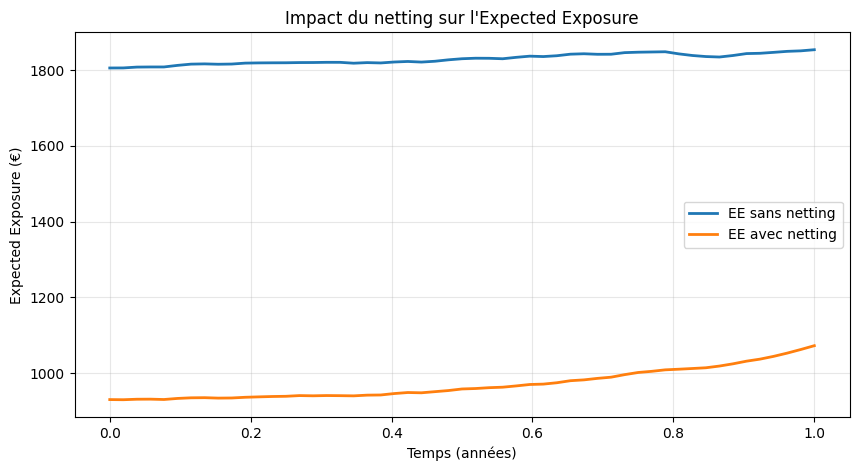

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    EE_gross,
    linewidth=2,
    label="EE sans netting"
)

plt.plot(
    times,
    EE_net,
    linewidth=2,
    label="EE avec netting"
)

plt.title(
    "Impact du netting sur l'Expected Exposure"
)

plt.xlabel("Temps (années)")
plt.ylabel("Expected Exposure (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Mesurer le bénéfice du netting

In [38]:
EPE_gross = np.mean(EE_gross)
EPE_net = np.mean(EE_net)

netting_benefit = (
    EPE_gross - EPE_net
)

netting_reduction = (
    netting_benefit / EPE_gross
)

print(
    f"EPE sans netting : "
    f"{EPE_gross:,.2f} €"
)

print(
    f"EPE avec netting : "
    f"{EPE_net:,.2f} €"
)

print(
    f"Réduction absolue : "
    f"{netting_benefit:,.2f} €"
)

print(
    f"Réduction relative : "
    f"{netting_reduction:.2%}"
)

EPE sans netting : 1,828.80 €
EPE avec netting : 971.33 €
Réduction absolue : 857.47 €
Réduction relative : 46.89%


## Comparer également le PFE

In [39]:
PFE95_gross = np.quantile(
    gross_exposure,
    0.95,
    axis=0
)

PFE95_net = np.quantile(
    net_exposure,
    0.95,
    axis=0
)

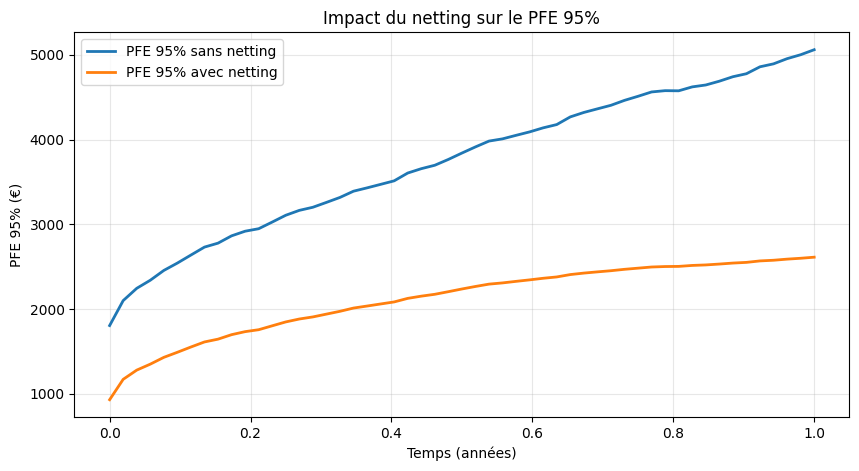

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    PFE95_gross,
    linewidth=2,
    label="PFE 95% sans netting"
)

plt.plot(
    times,
    PFE95_net,
    linewidth=2,
    label="PFE 95% avec netting"
)

plt.title(
    "Impact du netting sur le PFE 95%"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 95% (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Impact du netting sur la CVA

In [41]:
CVA_gross = np.sum(
    LGD
    * discount_factors[1:]
    * EE_gross[1:]
    * marginal_pd
)

In [42]:
CVA_net = np.sum(
    LGD
    * discount_factors[1:]
    * EE_net[1:]
    * marginal_pd
)

print(
    f"CVA sans netting : "
    f"{CVA_gross:,.2f} €"
)

print(
    f"CVA avec netting : "
    f"{CVA_net:,.2f} €"
)

print(
    f"Réduction de CVA : "
    f"{CVA_gross - CVA_net:,.2f} €"
)

CVA sans netting : 21.40 €
CVA avec netting : 11.37 €
Réduction de CVA : 10.03 €


### Interprétation

Les résultats montrent que le netting réduit l'exposition au risque de contrepartie en permettant de compenser les Mark-to-Market positifs et négatifs des transactions appartenant au même ensemble de compensation.

L'exposition nette est donc inférieure ou égale à l'exposition brute :

$$
E_t^{Net} \leq E_t^{Gross}
$$

Cette réduction se retrouve dans les indicateurs d'Expected Exposure, d'Expected Positive Exposure et de Potential Future Exposure.

La diminution du profil d'exposition entraîne également une réduction de la CVA, puisque la perte attendue en cas de défaut de la contrepartie devient plus faible.

Le netting constitue ainsi un mécanisme important de réduction du risque de contrepartie.

## 7. Collatéralisation du risque de contrepartie

Après avoir étudié l'effet du netting, nous introduisons un second mécanisme important de réduction du risque de contrepartie : le **collatéral**.

Dans les transactions sur produits dérivés, les contreparties peuvent échanger du collatéral afin de couvrir tout ou partie de leur exposition.

Lorsque la valeur nette du portefeuille devient suffisamment positive pour une partie, celle-ci peut demander à sa contrepartie de lui transférer du collatéral.

L'exposition résiduelle dépend alors de la valeur du portefeuille et du montant de collatéral disponible.

Dans cette section, nous comparons trois niveaux d'exposition :

1. exposition brute sans netting ;
2. exposition après netting ;
3. exposition après netting et collatéralisation.

### 7.1 Threshold

Le **Threshold** représente le niveau d'exposition qu'une contrepartie peut atteindre avant qu'un transfert de collatéral soit exigé.

Si le Mark-to-Market net du portefeuille reste inférieur au Threshold, aucun collatéral n'est demandé.

Lorsque le Mark-to-Market dépasse le Threshold, la partie excédentaire peut être couverte par du collatéral.

Dans une approche simplifiée :

$$
C_t = \max(V_t^{Net} - H, 0)
$$

où :

- $C_t$ représente le collatéral ;
- $V_t^{Net}$ représente le Mark-to-Market net du portefeuille ;
- $H$ représente le Threshold.

L'exposition après collatéral devient alors :

$$
E_t^{Coll}
=
\max(V_t^{Net} - C_t,0)
$$

Plus le Threshold est faible, plus le mécanisme de collatéralisation protège contre le risque de contrepartie.

### Première simulation du collatéral

In [43]:
# Paramètres de collatéralisation
threshold = 500.0

print(f"Threshold : {threshold:,.2f} €")

Threshold : 500.00 €


In [44]:
collateral = np.maximum(
    portfolio_mtm - threshold,
    0.0
)

print(
    "Dimension de la matrice de collatéral :",
    collateral.shape
)

Dimension de la matrice de collatéral : (10000, 53)


### 7.3 Exposition après collatéralisation

L'exposition résiduelle correspond à la valeur nette du portefeuille qui reste non couverte après prise en compte du collatéral.

Elle est calculée par :

$$
E_t^{Coll}
=
\max
\left(
V_t^{Net}-C_t,
0
\right)
$$

Le collatéral réduit donc l'exposition au défaut de la contrepartie sans nécessairement la supprimer totalement.

In [45]:
collateralized_exposure = np.maximum(
    portfolio_mtm - collateral,
    0.0
)

In [46]:
EE_collateral = np.mean(
    collateralized_exposure,
    axis=0
)

EPE_collateral = np.mean(
    EE_collateral
)

print(
    f"EPE sans netting : "
    f"{EPE_gross:,.2f} €"
)

print(
    f"EPE avec netting : "
    f"{EPE_net:,.2f} €"
)

print(
    f"EPE avec netting + collateral : "
    f"{EPE_collateral:,.2f} €"
)

EPE sans netting : 1,828.80 €
EPE avec netting : 971.33 €
EPE avec netting + collateral : 391.74 €


### Comparaison visuelle

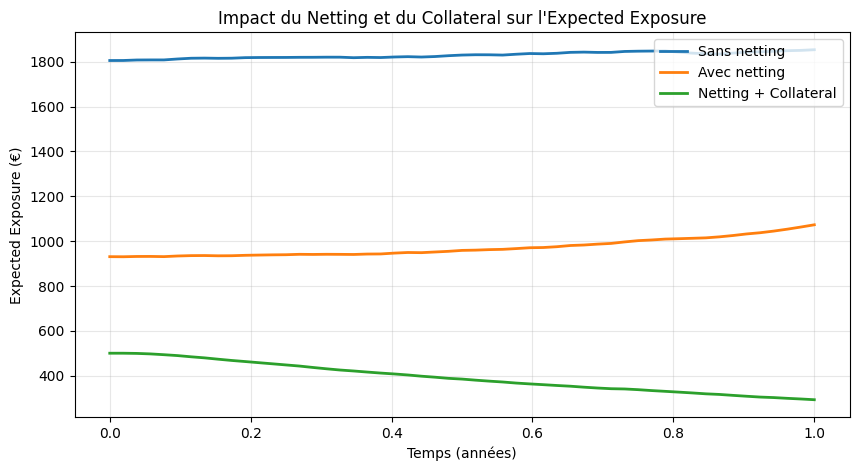

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    EE_gross,
    linewidth=2,
    label="Sans netting"
)

plt.plot(
    times,
    EE_net,
    linewidth=2,
    label="Avec netting"
)

plt.plot(
    times,
    EE_collateral,
    linewidth=2,
    label="Netting + Collateral"
)

plt.title(
    "Impact du Netting et du Collateral sur l'Expected Exposure"
)

plt.xlabel("Temps (années)")
plt.ylabel("Expected Exposure (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 7.5 Minimum Transfer Amount (MTA)

Le **Minimum Transfer Amount (MTA)** représente le montant minimum de collatéral devant être transféré.

Même lorsque l'exposition dépasse le Threshold, aucun transfert n'est effectué si le montant de collatéral à transférer est inférieur au MTA.

Ce mécanisme permet d'éviter des transferts de très faible montant dont le coût opérationnel serait disproportionné.

Dans notre modèle simplifié, un transfert de collatéral intervient lorsque :

$$
V_t^{Net} - H \geq MTA
$$

où :

- $H$ représente le Threshold ;
- $MTA$ représente le Minimum Transfer Amount.

In [48]:
threshold = 500.0
MTA = 100.0

In [49]:
required_collateral = np.maximum(
    portfolio_mtm - threshold,
    0.0
)

collateral_mta = np.where(
    required_collateral >= MTA,
    required_collateral,
    0.0
)

In [50]:
exposure_collateral_mta = np.maximum(
    portfolio_mtm - collateral_mta,
    0.0
)

EE_collateral_mta = np.mean(
    exposure_collateral_mta,
    axis=0
)

EPE_collateral_mta = np.mean(
    EE_collateral_mta
)

print(
    f"EPE avec Threshold + MTA : "
    f"{EPE_collateral_mta:,.2f} €"
)

EPE avec Threshold + MTA : 393.79 €


## PFE après collatéralisation

In [51]:
PFE95_collateral = np.quantile(
    exposure_collateral_mta,
    0.95,
    axis=0
)

PFE99_collateral = np.quantile(
    exposure_collateral_mta,
    0.99,
    axis=0
)

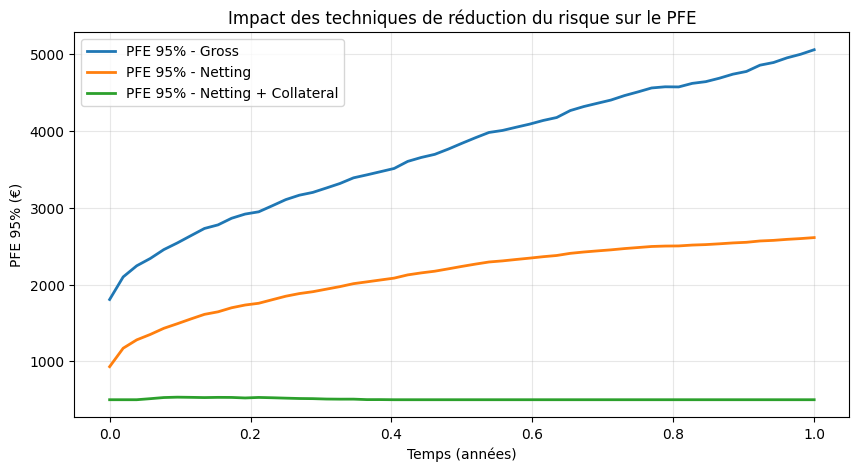

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    PFE95_gross,
    linewidth=2,
    label="PFE 95% - Gross"
)

plt.plot(
    times,
    PFE95_net,
    linewidth=2,
    label="PFE 95% - Netting"
)

plt.plot(
    times,
    PFE95_collateral,
    linewidth=2,
    label="PFE 95% - Netting + Collateral"
)

plt.title(
    "Impact des techniques de réduction du risque sur le PFE"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 95% (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Impact sur la CVA

In [53]:
CVA_collateral = np.sum(
    LGD
    * discount_factors[1:]
    * EE_collateral_mta[1:]
    * marginal_pd
)

In [54]:
print(f"CVA brute                 : {CVA_gross:,.2f} €")
print(f"CVA après netting         : {CVA_net:,.2f} €")
print(f"CVA netting + collateral  : {CVA_collateral:,.2f} €")

CVA brute                 : 21.40 €
CVA après netting         : 11.37 €
CVA netting + collateral  : 4.59 €


## Tableau récapitulatif

In [55]:
comparison = pd.DataFrame({
    "Configuration": [
        "Gross",
        "Netting",
        "Netting + Collateral"
    ],

    "EPE": [
        EPE_gross,
        EPE_net,
        EPE_collateral_mta
    ],

    "Max PFE 95%": [
        np.max(PFE95_gross),
        np.max(PFE95_net),
        np.max(PFE95_collateral)
    ],

    "CVA": [
        CVA_gross,
        CVA_net,
        CVA_collateral
    ]
})

comparison.round(2)

,Configuration,EPE,Max PFE 95%,CVA
0,Gross,1828.80,5059.00,21.40
1,Netting,971.33,2611.80,11.37
2,Netting + Collateral,393.79,533.27,4.59


### Interprétation

Les résultats mettent en évidence l'effet des mécanismes de réduction du risque de contrepartie.

Le **netting** permet de compenser les valeurs positives et négatives des transactions appartenant au même ensemble de compensation.

Le **collatéral** réduit ensuite l'exposition résiduelle en couvrant une partie du Mark-to-Market positif du portefeuille.

Le Threshold détermine le niveau d'exposition non collatéralisé accepté, tandis que le Minimum Transfer Amount évite les transferts de collatéral de faible montant.

La combinaison du netting et du collatéral entraîne ainsi une diminution de l'Expected Positive Exposure, du Potential Future Exposure et de la CVA.

Ces mécanismes constituent des outils essentiels de gestion et de réduction du risque de contrepartie sur les portefeuilles de produits dérivés.

## 8. Stress Testing et analyses de sensibilité

La mesure du risque de contrepartie ne doit pas uniquement reposer sur un scénario central. Il est également important d'évaluer la réaction du portefeuille à des conditions de marché ou de crédit plus défavorables.

Nous réalisons donc plusieurs analyses de sensibilité afin d'étudier l'impact de certains facteurs de risque sur les expositions et la CVA.

Les principaux facteurs étudiés sont :

- la volatilité du sous-jacent ;
- le hazard rate de la contrepartie ;
- le Recovery Rate ;
- les paramètres de collatéralisation.

Ces analyses permettent d'identifier les principaux déterminants du risque de contrepartie et d'évaluer la robustesse du portefeuille face à des scénarios défavorables.

### 8.1 Stress sur la volatilité

La volatilité constitue un facteur important dans la valorisation des options et dans la distribution des expositions futures.

Une augmentation de la volatilité entraîne une dispersion plus importante des scénarios futurs du sous-jacent et peut augmenter les valeurs extrêmes du portefeuille.

Nous étudions trois scénarios :

- scénario faible : $\sigma = 10\%$ ;
- scénario central : $\sigma = 20\%$ ;
- scénario stressé : $\sigma = 40\%$.

Pour chaque scénario, nous recalculons les trajectoires de marché, les Mark-to-Market du portefeuille et les indicateurs de risque.

## 8.2 Fonction de simulation sous différents niveaux de volatilité

In [56]:
def simulate_paths_with_volatility(
    S0,
    r,
    sigma_scenario,
    T,
    n_steps,
    Z
):
    """
    Génère les trajectoires du sous-jacent pour
    un niveau donné de volatilité en utilisant
    les mêmes chocs aléatoires Z.
    """

    dt = T / n_steps

    increments = (
        (r - 0.5 * sigma_scenario**2) * dt
        + sigma_scenario * np.sqrt(dt) * Z
    )

    log_paths = np.cumsum(
        increments,
        axis=1
    )

    scenario_paths = np.empty(
        (Z.shape[0], n_steps + 1)
    )

    scenario_paths[:, 0] = S0

    scenario_paths[:, 1:] = (
        S0 * np.exp(log_paths)
    )

    return scenario_paths

## 8.3 Fonction de revalorisation du portefeuille

In [57]:
def value_portfolio(
    scenario_paths,
    times,
    portfolio,
    r,
    sigma_scenario,
    T
):
    """
    Revalorise l'ensemble des transactions
    du portefeuille pour chaque scénario et chaque date.
    """

    portfolio_value = np.zeros_like(
        scenario_paths
    )

    for _, trade in portfolio.iterrows():

        trade_mtm = np.empty_like(
            scenario_paths
        )

        for j, t in enumerate(times):

            tau = T - t

            if trade["type"] == "call":

                unit_value = black_scholes_call_vectorized(
                    scenario_paths[:, j],
                    trade["strike"],
                    r,
                    sigma_scenario,
                    tau
                )

            else:

                unit_value = black_scholes_put_vectorized(
                    scenario_paths[:, j],
                    trade["strike"],
                    r,
                    sigma_scenario,
                    tau
                )

            trade_mtm[:, j] = (
                trade["quantity"]
                * unit_value
            )

        portfolio_value += trade_mtm

    return portfolio_value

## 8.4 Exécuter les trois scénarios

In [58]:
volatility_scenarios = {
    "Faible (10%)": 0.10,
    "Central (20%)": 0.20,
    "Stress (40%)": 0.40
}

vol_results = {}

In [59]:
for scenario_name, scenario_sigma in volatility_scenarios.items():

    # 1. Simulation des trajectoires
    scenario_paths = simulate_paths_with_volatility(
        S0=S0,
        r=r,
        sigma_scenario=scenario_sigma,
        T=T,
        n_steps=n_steps,
        Z=Z
    )

    # 2. Revalorisation du portefeuille
    scenario_mtm = value_portfolio(
        scenario_paths=scenario_paths,
        times=times,
        portfolio=portfolio,
        r=r,
        sigma_scenario=scenario_sigma,
        T=T
    )

    # 3. Exposition après netting
    scenario_exposure = np.maximum(
        scenario_mtm,
        0.0
    )

    # 4. Expected Exposure
    scenario_EE = np.mean(
        scenario_exposure,
        axis=0
    )

    # 5. EPE
    scenario_EPE = np.mean(
        scenario_EE
    )

    # 6. PFE 95%
    scenario_PFE95 = np.quantile(
        scenario_exposure,
        0.95,
        axis=0
    )

    # Sauvegarde
    vol_results[scenario_name] = {
        "sigma": scenario_sigma,
        "EE": scenario_EE,
        "EPE": scenario_EPE,
        "PFE95": scenario_PFE95
    }

## 8.5 Comparer les Expected Exposures

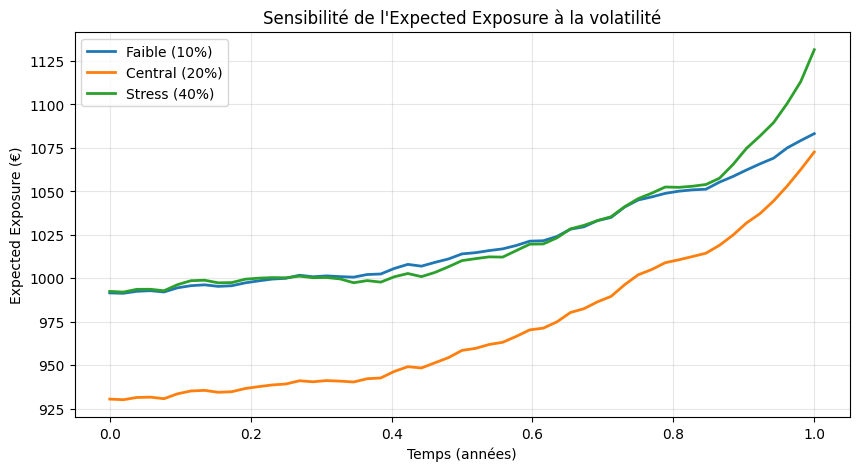

In [60]:
plt.figure(figsize=(10, 5))

for scenario_name, results in vol_results.items():

    plt.plot(
        times,
        results["EE"],
        linewidth=2,
        label=scenario_name
    )

plt.title(
    "Sensibilité de l'Expected Exposure à la volatilité"
)

plt.xlabel("Temps (années)")
plt.ylabel("Expected Exposure (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8.6 Comparer les PFE

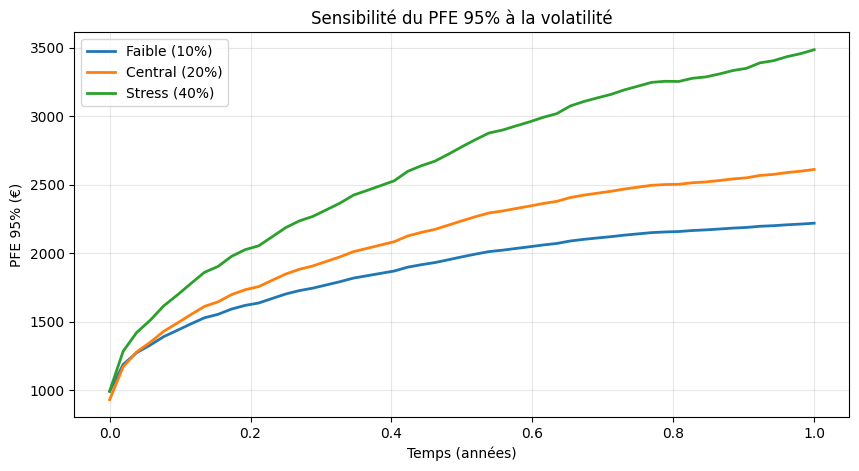

In [61]:
plt.figure(figsize=(10, 5))

for scenario_name, results in vol_results.items():

    plt.plot(
        times,
        results["PFE95"],
        linewidth=2,
        label=scenario_name
    )

plt.title(
    "Sensibilité du PFE 95% à la volatilité"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 95% (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8.7 Tableau de synthèse

In [62]:
vol_summary = pd.DataFrame([
    {
        "Scénario": scenario_name,
        "Volatilité": results["sigma"],
        "EPE": results["EPE"],
        "Max PFE 95%": np.max(
            results["PFE95"]
        )
    }

    for scenario_name, results
    in vol_results.items()
])

vol_summary["Volatilité"] = (
    vol_summary["Volatilité"]
    .map(lambda x: f"{x:.0%}")
)

vol_summary.round(2)

,Scénario,Volatilité,EPE,Max PFE 95%
0,Faible (10%),10%,1021.54,2219.32
1,Central (20%),20%,971.33,2611.80
2,Stress (40%),40%,1024.13,3485.86


### 8.2 Stress sur la qualité de crédit de la contrepartie

Nous analysons maintenant l'effet d'une dégradation de la qualité de crédit de la contrepartie.

Cette dégradation est représentée par une augmentation du hazard rate.

Nous considérons trois scénarios :

- faible risque de crédit : $\lambda = 1\%$ ;
- scénario central : $\lambda = 2\%$ ;
- scénario stressé : $\lambda = 5\%$.

Toutes choses égales par ailleurs, une augmentation du hazard rate augmente la probabilité de défaut de la contrepartie et devrait donc augmenter la CVA.

In [63]:
hazard_scenarios = {
    "Faible (1%)": 0.01,
    "Central (2%)": 0.02,
    "Stress (5%)": 0.05
}

hazard_results = []

In [64]:
for scenario_name, lambda_scenario in hazard_scenarios.items():

    # Probabilité de survie
    survival = np.exp(
        -lambda_scenario * times
    )

    # PD marginales
    marginal_default = (
        survival[:-1]
        - survival[1:]
    )

    # CVA
    scenario_cva = np.sum(
        LGD
        * discount_factors[1:]
        * EE_net[1:]
        * marginal_default
    )

    # PD cumulée
    pd_1y = 1 - survival[-1]

    hazard_results.append({
        "Scénario": scenario_name,
        "Hazard Rate": lambda_scenario,
        "PD 1 an": pd_1y,
        "CVA": scenario_cva
    })

In [65]:
hazard_summary = pd.DataFrame(
    hazard_results
)

hazard_summary

,Scénario,Hazard Rate,PD 1 an,CVA
0,Faible (1%),0.01,0.009950,5.713405
1,Central (2%),0.02,0.019801,11.368995
2,Stress (5%),0.05,0.048771,27.994661


## 8.9 Visualiser l'impact sur la CVA

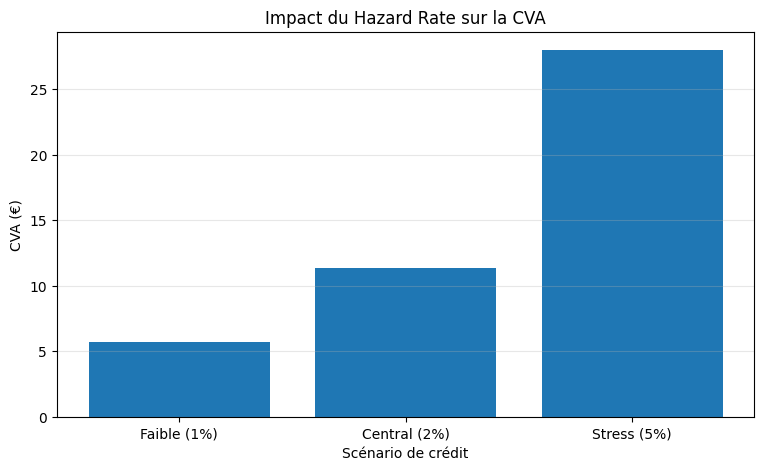

In [66]:
plt.figure(figsize=(9, 5))

plt.bar(
    hazard_summary["Scénario"],
    hazard_summary["CVA"]
)

plt.title(
    "Impact du Hazard Rate sur la CVA"
)

plt.xlabel("Scénario de crédit")
plt.ylabel("CVA (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 8.3 Sensibilité au Recovery Rate

Le Recovery Rate représente la proportion de l'exposition susceptible d'être récupérée après le défaut de la contrepartie.

Comme :

$$
LGD = 1-R
$$

une diminution du Recovery Rate augmente la Loss Given Default et, toutes choses égales par ailleurs, augmente la CVA.

Nous étudions plusieurs hypothèses de taux de récupération afin de mesurer cette sensibilité.

In [67]:
recovery_scenarios = [
    0.20,
    0.40,
    0.60
]

recovery_results = []

for recovery in recovery_scenarios:

    scenario_lgd = 1 - recovery

    scenario_cva = np.sum(
        scenario_lgd
        * discount_factors[1:]
        * EE_net[1:]
        * marginal_pd
    )

    recovery_results.append({
        "Recovery Rate": recovery,
        "LGD": scenario_lgd,
        "CVA": scenario_cva
    })

recovery_summary = pd.DataFrame(
    recovery_results
)

recovery_summary

,Recovery Rate,LGD,CVA
0,0.2,0.8,15.158660
1,0.4,0.6,11.368995
2,0.6,0.4,7.579330


### Conclusion des analyses de sensibilité

Les analyses de sensibilité permettent d'identifier les principaux facteurs influençant le risque de contrepartie.

Le stress de volatilité modifie la distribution des valeurs futures du portefeuille et influence ainsi les profils d'Expected Exposure et de Potential Future Exposure. L'ampleur de cet effet dépend de la composition du portefeuille et des mécanismes de netting.

La dégradation de la qualité de crédit de la contrepartie, représentée par une augmentation du hazard rate, entraîne une augmentation de la probabilité de défaut et de la CVA.

Enfin, une diminution du Recovery Rate augmente la Loss Given Default et conduit également à une augmentation de la CVA.

Ces analyses montrent que le risque de contrepartie résulte de l'interaction entre le risque de marché, l'exposition du portefeuille et la qualité de crédit de la contrepartie.